<a href="https://colab.research.google.com/github/MMujtabaX/tfidf-search-engine/blob/main/tfidf_search_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TF-IDF in Practice: Keyword Extraction & a Document Search Engine

TF-IDF scores how important a word is to **one document** relative to a **whole collection**:

$$\text{tf-idf}(t, d) = \text{tf}(t, d) \times \log\frac{1 + N}{1 + \text{df}(t)} + 1$$

A word scores high when it's frequent in a document but rare across the collection. That makes TF-IDF useful well beyond feature extraction for classifiers. In this notebook we use it to build:

1. **A document loader** for your own PDFs (e.g. research papers), with a news-corpus fallback
2. **Keyword extraction:** the words that best describe each document and each topic
3. **A search engine:** rank documents against a free-text query with cosine similarity, and **evaluate** it
4. **"More like this":** find articles similar to a given one
5. **A topic map:** project 10,000 documents into 2D with latent semantic analysis (LSA)

We use the **Reuters-21578** news corpus: 10,788 business articles labelled with topics such as *earnings*, *acquisitions*, *crude oil* and *grain*.

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('reuters', quiet=True)
pd.set_option('display.max_colwidth', 80)

---
## 1. Loading Documents

### Option A: your own PDFs

The function below extracts text from every PDF in a folder with `pypdf`, a pure-Python library that needs no Java (unlike Apache Tika). In Colab, upload PDFs to a folder like `/content/papers` and set `PDF_FOLDER` to use them instead of the news corpus.

In [2]:
import os

def load_pdfs(folder):
    """Extract text from every PDF in `folder`. Returns a DataFrame with title and text."""
    from pypdf import PdfReader
    rows = []
    for name in sorted(os.listdir(folder)):
        if name.lower().endswith('.pdf'):
            try:
                reader = PdfReader(os.path.join(folder, name))
                text = " ".join(page.extract_text() or "" for page in reader.pages)
                rows.append({'title': os.path.splitext(name)[0], 'text': text, 'topic': 'pdf'})
            except Exception as e:
                print(f"Skipped {name}: {e}")
    return pd.DataFrame(rows)

PDF_FOLDER = None   # e.g. "/content/papers"

### Option B: the Reuters news corpus (used in this notebook)

In [3]:
from nltk.corpus import reuters

if PDF_FOLDER:
    docs = load_pdfs(PDF_FOLDER)
else:
    rows = []
    for fid in reuters.fileids():
        raw = reuters.raw(fid)
        title, _, body = raw.partition('\n')
        cats = reuters.categories(fid)
        rows.append({'id': fid, 'title': title.strip().title(), 'text': raw, 'cats': cats,
                     'topics': ", ".join(cats),
                     'topic': cats[0] if len(cats) == 1 else 'multi'})
    # Reuters contains some exact duplicate articles; keep one copy of each
    docs = pd.DataFrame(rows).drop_duplicates('text').reset_index(drop=True)

docs['n_words'] = docs['text'].str.split().str.len()
print(f"Documents: {len(docs):,}")
print(f"Median length: {docs.n_words.median():.0f} words")
docs[['title', 'topics', 'n_words']].head()

Documents: 10,657
Median length: 84 words


,title,topics,n_words
0,Asian Exporters Fear Damage From U.S.-Japan Rift,trade,713
1,China Daily Says Vermin Eat 7-12 Pct Grain Stocks,grain,108
2,Japan To Revise Long-Term Energy Demand Downwards,"crude, nat-gas",173
3,Thai Trade Deficit Widens In First Quarter,"corn, grain, rice, rubber, sugar, tin, trade",148
4,Indonesia Sees Cpo Price Rising Sharply,"palm-oil, veg-oil",158


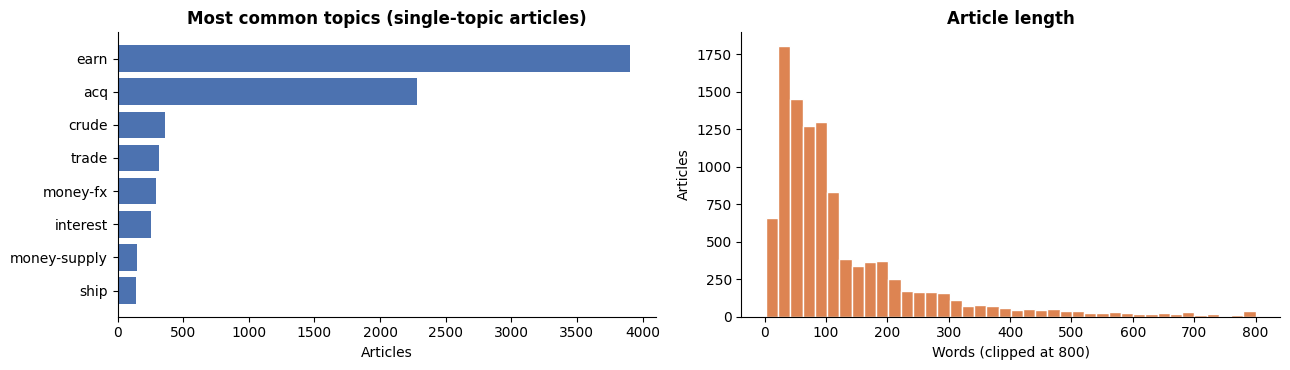

In [4]:
top_topics = docs[docs.topic != 'multi'].topic.value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].barh(top_topics.index[::-1], top_topics.values[::-1], color='#4C72B0')
axes[0].set_title('Most common topics (single-topic articles)', fontweight='bold')
axes[0].set_xlabel('Articles')
axes[1].hist(docs.n_words.clip(upper=800), bins=40, color='#DD8452', edgecolor='white')
axes[1].set_title('Article length', fontweight='bold')
axes[1].set_xlabel('Words (clipped at 800)')
axes[1].set_ylabel('Articles')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 2. Building the TF-IDF Matrix

Settings chosen for real text rather than toy examples:

| Setting | Value | Why |
|---------|-------|-----|
| `stop_words` | English + news words | Drop "the", "and", plus Reuters filler like "said", "pct", "mln", "dlrs" |
| `token_pattern` | words of 3+ letters | Skip numbers, single letters and two-letter fragments |
| `min_df` | 3 | Ignore typos and words seen in fewer than 3 documents |
| `max_df` | 0.5 | Ignore words in more than half of all documents |
| `sublinear_tf` | True | Use 1 + log(tf), so a word repeated 20× doesn't count 20× more |
| `ngram_range` | (1, 2) | Also capture phrases like "interest rates" and "crude oil" |

In [5]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Reuters "house style" words that appear everywhere and carry no topic: said, pct, mln, dlrs, cts ...
news_stopwords = list(ENGLISH_STOP_WORDS | {'said', 'reuter', 'pct', 'mln', 'dlrs', 'cts', 'shr', 'vs', 'billion', 'year'})

vectorizer = TfidfVectorizer(stop_words=news_stopwords, token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
                             min_df=3, max_df=0.5, sublinear_tf=True, ngram_range=(1, 2))
X = vectorizer.fit_transform(docs['text'])
terms = vectorizer.get_feature_names_out()

density = X.nnz / (X.shape[0] * X.shape[1])
print(f"TF-IDF matrix: {X.shape[0]:,} documents × {X.shape[1]:,} terms")
print(f"Non-zero entries: {X.nnz:,} ({density:.3%} of the matrix), so it's stored sparse")

TF-IDF matrix: 10,657 documents × 43,064 terms
Non-zero entries: 662,575 (0.144% of the matrix), so it's stored sparse


---
## 3. Keyword Extraction

### Raw frequency vs TF-IDF on one article

Which words "describe" an article? Plain counting favors words that are common everywhere. TF-IDF favors words that are distinctive to this article.

Article: Asian Exporters Fear Damage From U.S.-Japan Rift 



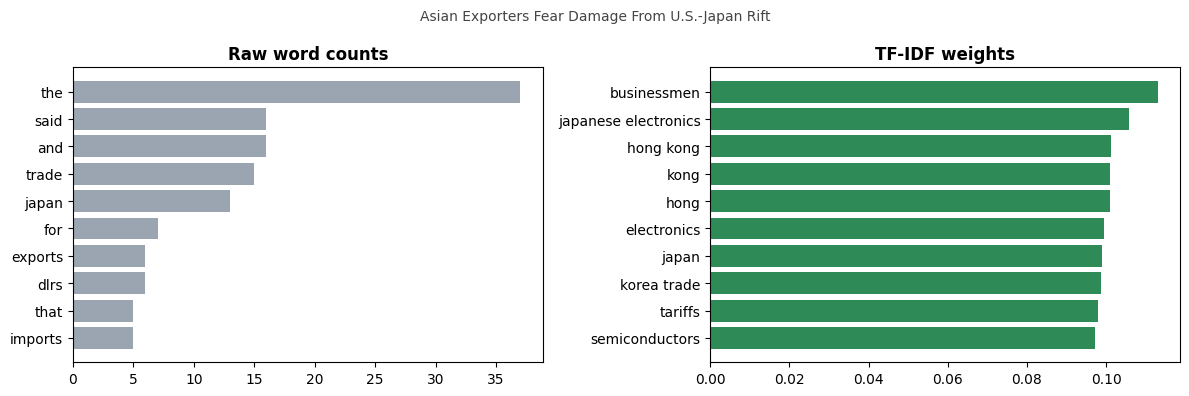

In [6]:
counter = CountVectorizer(token_pattern=r"(?u)\b[a-zA-Z]{3,}\b")
C = counter.fit_transform(docs['text'])
count_terms = counter.get_feature_names_out()

def top_terms(row, vocab, k=10):
    row = row.toarray().ravel()
    idx = row.argsort()[::-1][:k]
    return [(vocab[i], row[i]) for i in idx if row[i] > 0]

i = docs.index[docs.title.str.contains('Asian Exporters Fear Damage', case=False)][0]
print("Article:", docs.title[i], "\n")

freq = top_terms(C[i], count_terms)
tfidf = top_terms(X[i], terms)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title, color in [(axes[0], freq, 'Raw word counts', '#9AA5B1'),
                               (axes[1], tfidf, 'TF-IDF weights', '#2E8B57')]:
    words, vals = zip(*data)
    ax.barh(words[::-1], vals[::-1], color=color)
    ax.set_title(title, fontweight='bold')
fig.suptitle(docs.title[i], fontsize=10, color='#444')
plt.tight_layout()
plt.show()

Raw counts are dominated by words that appear in almost every article (*the*, *said*, *and*, *for*). TF-IDF surfaces what this story is specifically about (*japanese electronics*, *semiconductors*, *tariffs*, *hong kong*, *korea trade*), including multi-word phrases thanks to bigrams.

### Keywords for a few articles

In [7]:
sample = docs[docs.topic.isin(['crude', 'grain', 'acq', 'money-fx', 'ship'])].groupby('topic').head(1)
pd.DataFrame({
    'title': sample.title.values,
    'topic': sample.topic.values,
    'top TF-IDF keywords': [", ".join(t for t, _ in top_terms(X[j], terms, k=6)) for j in sample.index],
})

,title,topic,top TF-IDF keywords
0,China Daily Says Vermin Eat 7-12 Pct Grain Stocks,grain,"preservation, grain stocks, china, china daily, waste, storage"
1,Australian Foreign Ship Ban Ends But Nsw Ports Hit,ship,"nsw, ports, ban, cargo handling, disruption, disrupted"
2,Sumitomo Bank Aims At Quick Recovery From Merger,acq,"komatsu, sumitomo, securities business, bold, sumitomo bank, kleinwort"
3,Stoltenberg Sees Moves To Strengthen Paris Accord,money-fx,"stoltenberg, poehl, paris, paris accord, louvre, louvre agreement"
4,Turkey Calls For Dialogue To Solve Dispute,crude,"turkey, greece, solved, aegean, continental shelf, message"


### What defines each topic?

Averaging TF-IDF vectors across all articles in a topic gives that topic's signature vocabulary, an unsupervised topic summary.

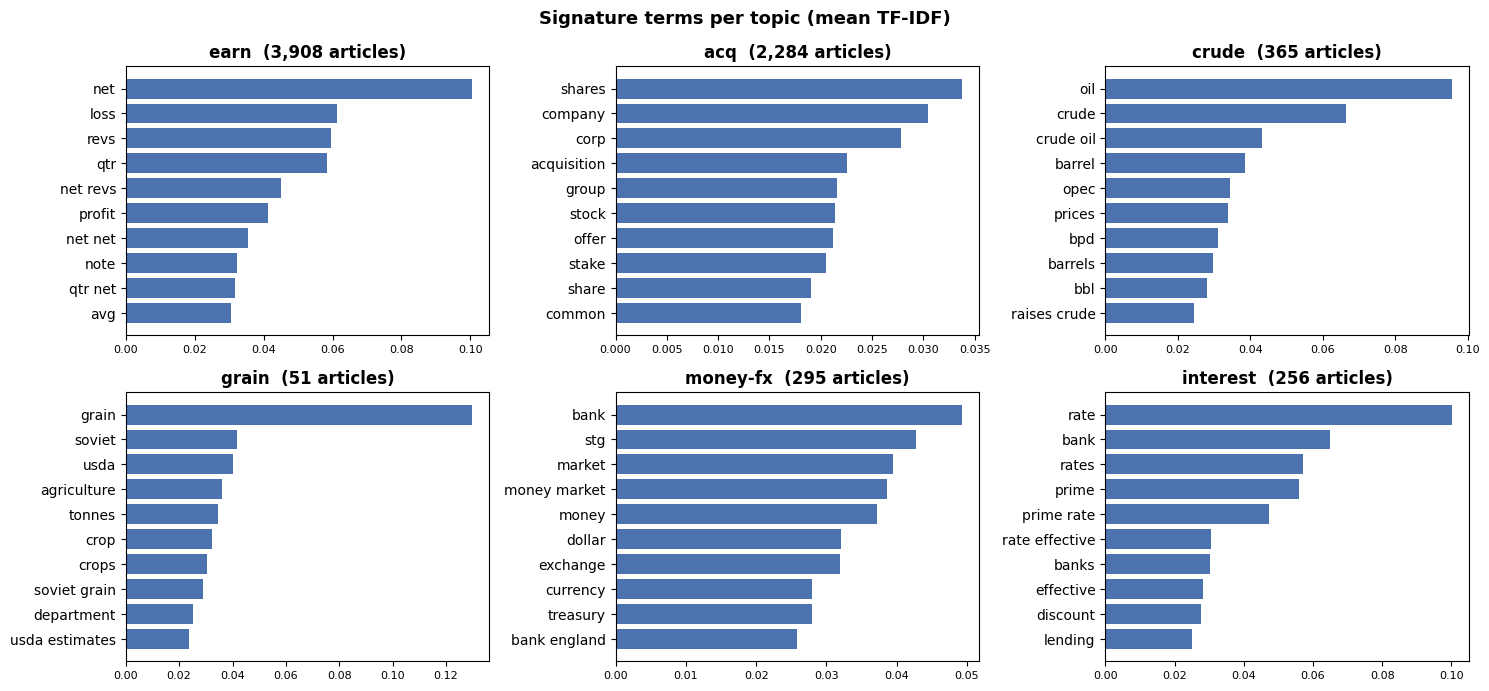

In [8]:
topics = ['earn', 'acq', 'crude', 'grain', 'money-fx', 'interest']
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, t in zip(axes.ravel(), topics):
    mask = (docs.topic == t).values
    mean_vec = np.asarray(X[mask].mean(axis=0)).ravel()
    idx = mean_vec.argsort()[::-1][:10]
    ax.barh(terms[idx][::-1], mean_vec[idx][::-1], color='#4C72B0')
    ax.set_title(f"{t}  ({mask.sum():,} articles)", fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
plt.suptitle('Signature terms per topic (mean TF-IDF)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. A TF-IDF Search Engine

A query is just a very short document. Transform it with the **same fitted vectorizer**, then rank every article by **cosine similarity**:

$$\cos(q, d) = \frac{q \cdot d}{\lVert q \rVert \, \lVert d \rVert}$$

TF-IDF vectors are already L2-normalized, so this is a single sparse matrix–vector product over all 10,788 documents.

In [9]:
def search(query, k=5, matrix=X, vec=vectorizer):
    q = vec.transform([query])
    scores = cosine_similarity(q, matrix).ravel()
    top = scores.argsort()[::-1][:k]
    return pd.DataFrame({'score': scores[top].round(3),
                         'title': docs.title.values[top],
                         'topics': docs.topics.values[top]})

search("opec oil production cut")

,score,title,topics
0,0.222,Egyptian 1986 Crude Oil Output Down On 1985,crude
1,0.203,Saudi Success Seen In Curbing Opec Production,crude
2,0.197,Overseas &Lt;Osg> Sees Opec Quotas Key To Rates,"crude, ship"
3,0.183,Argentine Oil Production Down In January 1987,"crude, nat-gas"
4,0.177,Opec May Have To Meet To Firm Prices - Analysts,crude


In [10]:
for q in ["soviet union wheat purchase", "federal reserve interest rate", "takeover bid shareholders"]:
    print(f"\n🔎 {q}")
    print(search(q, k=4).to_string(index=False))


🔎 soviet union wheat purchase
 score                                         title                                        topics
 0.372      French Cereal Exports Through Rouen Fall barley, corn, grain, oilseed, rapeseed, wheat
 0.306   U.S. Wheat Growers Want Eep To Soviet Union                            corn, grain, wheat
 0.255    U.S. Senate Group Urges Subsidies For Ussr                                  grain, wheat
 0.255 U.S. Willing To Talk To Moscow On Wheat Price                            corn, grain, wheat

🔎 federal reserve interest rate
 score                                           title             topics
 0.244    Fed Not Expected To Take Money Market Action interest, money-fx
 0.228 Institute Of Clinical Pharm Plc &Lt;Icpyy> Year               earn
 0.213   White House Says U.S. Monetary Policy Correct           money-fx
 0.203 Volcker Says Fed Policy Not Linked To Rate Rise           interest

🔎 takeover bid shareholders
 score                                    

### Evaluating the search engine

Search quality can be measured, not just eyeballed. Using Reuters' topic labels as relevance judgments, we compute **Precision@10**: the share of the top 10 results tagged with the topic the query is about.

We compare four ways of building document vectors:

| Configuration | Weighting | Stopwords & df filtering |
|---------------|-----------|--------------------------|
| Raw counts | word counts | ❌ |
| Filtered counts | word counts | ✅ |
| TF-IDF (unfiltered) | TF-IDF | ❌ |
| TF-IDF (full) | TF-IDF, sublinear tf, bigrams | ✅ |

And two styles of query:
- **Keyword queries**, as a search-savvy user would type them: *"crude oil prices opec"*
- **Natural-language questions**, full of common words: *"what are analysts saying about the price of crude oil"*

In [11]:
token_pattern = r"(?u)\b[a-zA-Z]{3,}\b"
configs = {
    'Raw counts':          CountVectorizer(token_pattern=token_pattern),
    'Filtered counts':     CountVectorizer(stop_words=news_stopwords, token_pattern=token_pattern,
                                           min_df=3, max_df=0.5, ngram_range=(1, 2)),
    'TF-IDF (unfiltered)': TfidfVectorizer(token_pattern=token_pattern),
    'TF-IDF (full)':       vectorizer,
}
matrices = {name: (X if name == 'TF-IDF (full)' else v.fit_transform(docs['text'])) for name, v in configs.items()}

keyword_queries = {
    'crude oil prices opec': 'crude',          'wheat grain exports harvest': 'grain',
    'company acquires stake merger': 'acq',    'quarterly net profit dividend': 'earn',
    'dollar yen currency exchange': 'money-fx', 'central bank interest rates': 'interest',
    'shipping port vessels strike': 'ship',    'trade deficit tariffs': 'trade',
    'sugar production tonnes': 'sugar',        'coffee export quotas': 'coffee',
    'gold mine ounces': 'gold',                'soybean crop usda': 'soybean',
}
question_queries = {
    'what are analysts saying about the price of crude oil': 'crude',
    'has the government decided on wheat exports this year': 'grain',
    'which company said it will acquire the shares of another company': 'acq',
    'the company said its net profit and dividend rose in the quarter': 'earn',
    'how did the dollar move against the yen on the market today': 'money-fx',
    'will the bank raise or cut its interest rates this week': 'interest',
    'were the ships and ports affected by the strike': 'ship',
    'what is the latest on the trade deficit and the tariffs': 'trade',
    'how much sugar will be produced this season': 'sugar',
    'what did the producers say about the coffee export quota': 'coffee',
    'the mining company reported gold output in ounces': 'gold',
    'what does the usda expect for the soybean crop': 'soybean',
}

def precision_at_10(query, topic, vec, matrix):
    scores = cosine_similarity(vec.transform([query]), matrix).ravel()
    top = scores.argsort()[::-1][:10]
    return np.mean([topic in docs.cats.iloc[i] for i in top])

results = pd.DataFrame({
    query_set: {name: np.mean([precision_at_10(q, t, configs[name], matrices[name]) for q, t in qs.items()])
                for name in configs}
    for query_set, qs in [('Keyword queries', keyword_queries), ('Natural-language questions', question_queries)]
})
results.round(3)

,Keyword queries,Natural-language questions
Raw counts,0.933,0.750
Filtered counts,0.892,0.925
TF-IDF (unfiltered),0.942,0.883
TF-IDF (full),0.892,0.917


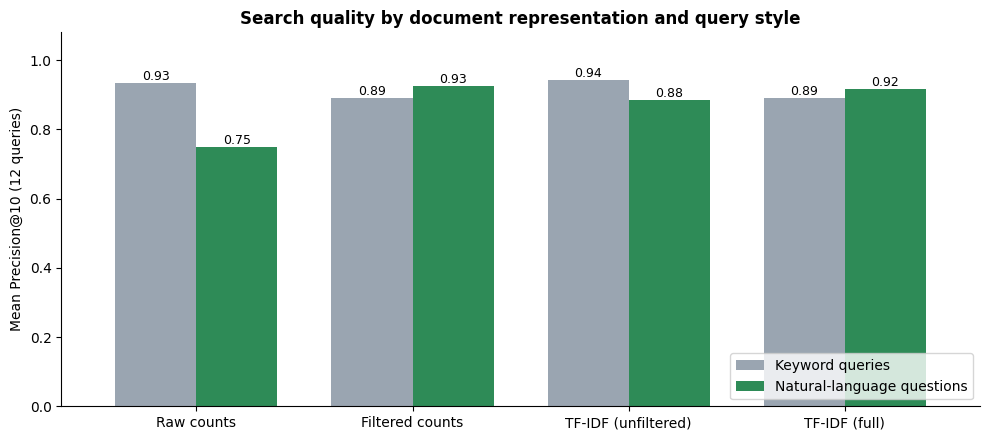

In [12]:
ax = results.plot.bar(figsize=(10, 4.5), color=['#9AA5B1', '#2E8B57'], width=0.75, rot=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)
ax.set_ylabel('Mean Precision@10 (12 queries)')
ax.set_ylim(0, 1.08)
ax.set_title('Search quality by document representation and query style', fontweight='bold')
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**What the evaluation shows:**
- **Keyword queries are easy for every method** (0.89–0.94). When a query contains only distinctive words, any representation finds relevant articles.
- **Natural-language questions expose raw counts** (0.75). Common words like *"the"*, *"what"* and *"said"* dominate the similarity and pull in irrelevant articles.
- **Two different fixes work:** IDF weighting alone (0.88) down-weights common words **automatically**, without any word list, while an explicit stopword list removes them outright (0.92–0.93).
- **Once stopwords are removed, TF-IDF adds little on top of counts here** (0.92 vs 0.93, a difference of about one result across 12 queries). The filtering also costs a little on keyword queries (0.94 → 0.89), a reminder that every preprocessing choice is a trade-off.

> **Caveat:** topic labels are a rough proxy for relevance, and 12 queries per set is a small sample, so small differences shouldn't be over-interpreted. Real search evaluation uses many queries with human relevance judgments.

---
## 5. "More Like This": Similar Documents

The same idea works document-to-document: compare one article's TF-IDF vector with all others.

In [13]:
def more_like_this(idx, k=5):
    scores = cosine_similarity(X[idx], X).ravel()
    scores[idx] = -1                       # exclude the article itself
    top = scores.argsort()[::-1][:k]
    return pd.DataFrame({'similarity': scores[top].round(3),
                         'title': docs.title.values[top], 'topics': docs.topics.values[top]})

j = docs.index[(docs.topic == 'crude')][3]
print("Source article:", docs.title[j], f"[{docs.topic[j]}]\n")
more_like_this(j)

Source article: U.S. Oil Dependency Seen Rising To Record Level [crude]



,similarity,title,topics
0,0.226,Division Seen On How To Help U.S. Oil Industry,"crude, nat-gas"
1,0.215,Reagan Says U.S. Needs To Lessen Oil Imports,crude
2,0.204,Energy Analyst Proposes U.S. Oil Tariff,crude
3,0.171,Exxon (Xon) Sees Synfuels Role By Year 2000,crude
4,0.152,Study Predicts U.S. Dependence On Foreign Oil,crude


---
## 6. A Map of the News: Latent Semantic Analysis

TF-IDF vectors have tens of thousands of dimensions. **Truncated SVD**, known in NLP as **latent semantic analysis (LSA)**, compresses them into a few "concept" dimensions. Projecting to 2D, with no labels involved, reveals the dominant structure of the collection.

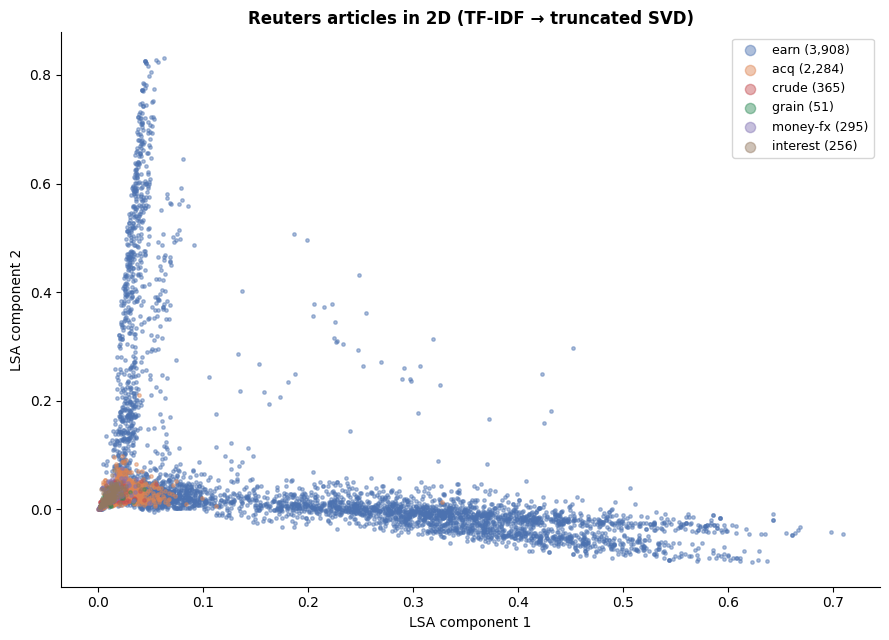

Component 1 top terms: net, revs, loss, qtr, net revs, profit, net net, avg
Component 2 top terms: qtly, div, qtly div, record, div prior, pay, prior, april


In [14]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X)

plot_topics = ['earn', 'acq', 'crude', 'grain', 'money-fx', 'interest']
colors = ['#4C72B0', '#DD8452', '#C44E52', '#2E8B57', '#8172B3', '#937860']

plt.figure(figsize=(9, 6.5))
for t, c in zip(plot_topics, colors):
    m = (docs.topic == t).values
    plt.scatter(coords[m, 0], coords[m, 1], s=6, alpha=0.45, color=c, label=f"{t} ({m.sum():,})")
plt.xlabel('LSA component 1')
plt.ylabel('LSA component 2')
plt.title('Reuters articles in 2D (TF-IDF → truncated SVD)', fontweight='bold')
plt.legend(markerscale=3, fontsize=9)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# What each LSA direction "means"
for i, comp in enumerate(svd.components_):
    print(f"Component {i + 1} top terms:", ", ".join(terms[comp.argsort()[::-1][:8]]))

The two strongest directions in the collection are both about **corporate finance**: component 1 is **earnings reports** (*net*, *revs*, *loss*, *qtr*, *profit*) and component 2 is **dividend announcements** (*qtly div*, *record*, *pay*). Reuters publishes thousands of short, formulaic earnings and dividend notices, and their repetitive vocabulary is the largest source of variation in the corpus. That's why earnings articles spread out along their own axes, while the other topics cluster nearer the origin, separated by smaller differences.

---
## Summary

| Application | How TF-IDF is used |
|-------------|--------------------|
| Keyword extraction | Highest-weighted terms in a document's vector |
| Topic signatures | Mean TF-IDF vector across a topic's documents |
| Search engine | Query vector ranked against documents by cosine similarity |
| Similar documents | Document-to-document cosine similarity |
| Topic map | TF-IDF → truncated SVD (LSA) into 2D |

**Limitations:** TF-IDF matches **exact words**, so a search for "car" won't find "automobile", and it ignores word order. **Dense embeddings** (Word2Vec, sentence transformers) address both and power modern semantic search, but TF-IDF and its cousin **BM25** are still widely used as fast, explainable baselines and in hybrid search systems.